# Experiment No. 8 — Advanced Implementation

# 🌳 Advanced Dependency Parsing, Syntactic & Semantic Tree Traversal, Structural Ambiguity Resolution, and Relation Extraction

> **Domain:** Natural Language Processing (NLP)  
> **Level:** Advanced / Mastery  
> **Course:** SPPU Engineering Curriculum (AI & Data Science)  
> **Author:** Himanshu Jadhav (Roll No: TE-32)

---

## 📌 Experiment Overview

| Parameter | Details |
| :--- | :--- |
| **Experiment Number** | 08 |
| **Basic Objective** | Perform dependency parsing with spaCy on a toy sentence, identify subject/object modifiers, render a basic displaCy tree, and note one ambiguous sentence. |
| **Advanced Objective** | Construct a comprehensive syntactic analysis framework capable of (1) recursive ASCII dependency tree visualization, (2) formal tree metric analysis (depth, branching factor, mean dependency distance), (3) robust Subject-Verb-Object (SVO) event triple extraction handling active/passive voice, (4) algorithmic Prepositional Phrase (PP) attachment ambiguity resolution, (5) multi-clause decomposition, (6) a Syntactic Complexity Index (SCI), and (7) a reusable OOP pipeline. |
| **Prerequisites** | Dependency Grammar, Universal Dependencies (UD v2), Context-Free Grammars, Graph Theory, spaCy, NLTK. |
| **Target Runtime** | Jupyter Notebook / Python 3.10+ (`nlp_env`) |

---

### 💡 Basic vs. Advanced Comparison

```
+---------------------------------------------------------------------------------------------------+
|                                      EVOLUTION OF TECHNIQUE                                        |
+---------------------------------------------------------------------------------------------------+
| BASIC PRACTICAL                                                                                   |
| - 2 simple toy sentences                                                                          |
| - Standard displaCy tree rendering                                                                |
| - Surface-level token-head inspection without recursive traversal                                 |
| - No quantitative structural metrics (tree depth, branching factor)                               |
| - Ambiguity noted purely qualitatively                                                            |
+---------------------------------------------------------------------------------------------------+
                                                  |
                                                  v
+---------------------------------------------------------------------------------------------------+
| ADVANCED PRACTICAL                                                                                |
| - Complex Linguistic Benchmark Corpus (PP-Attachment, Garden Paths, Center Embedding, Passives)   |
| - Recursive Tree Graph Traversal Engine with ASCII Hierarchy Rendering                            |
| - Formal Tree Topometry: Maximum Depth, Branching Factor, Mean Dependency Distance (MDD)          |
| - Active/Passive-Aware Subject-Verb-Object (SVO) Event Triple Mining                              |
| - Heuristic & Lexical Affinity Prepositional Phrase Attachment Arbiter                            |
| - Clausal Decomposition (Matrix, Relative relcl, Adverbial advcl, Complement xcomp)               |
| - Syntactic Complexity Index (SCI) and Dependency-Guided Fact Extraction                          |
| - Modular Reusable OOP Pipeline (AdvancedSyntacticPipeline)                                       |
+---------------------------------------------------------------------------------------------------+
```


## 1. 🧠 Conceptual & Mathematical Foundation

### 1.1 Dependency vs. Constituency Grammar
- **Constituency Grammar (Phrase Structure):** Decomposes sentences hierarchically into nested non-terminal phrases ($S \to NP + VP$).
- **Dependency Grammar:** Directly links lexical tokens via directed binary grammatical relations $(\text{Head} \xrightarrow{\text{dep}} \text{Dependent})$. No non-terminal nodes are introduced, making it compact and word-order invariant.

### 1.2 Universal Dependencies (UD v2) Relational Taxonomy
Universal Dependencies standardizes grammatical relations across human languages into:
- **Core Nominal Arguments:** `nsubj` (nominal subject), `obj` / `dobj` (direct object), `iobj` (indirect object).
- **Passive Core Arguments:** `nsubj:pass` / `nsubjpass` (passive nominal subject), `agent` / `obl:agent` (agentive by-phrase).
- **Non-Core Clausal Dependents:** `advcl` (adverbial clause), `relcl` (relative clause modifier), `xcomp` (open clausal complement).
- **Nominal Modifiers:** `amod` (adjectival modifier), `nmod` (nominal modifier), `det` (determiner).

### 1.3 Transition-Based Parsing (Arc-Standard / Arc-Eager)
A transition parser maintains a state configuration:
$$C = (\sigma, \beta, A)$$
where $\sigma$ is a stack of active words, $\beta$ is a buffer of unread tokens, and $A$ is the set of established dependency arcs.
Transitions:
1. **SHIFT:** Moves the front token of $\beta$ onto the top of $\sigma$.
2. **LEFT-ARC ($l$):** Adds arc $(w_j \xrightarrow{l} w_i)$ where $w_i = \sigma[top-1]$ and $w_j = \sigma[top]$; pops $w_i$.
3. **RIGHT-ARC ($l$):** Adds arc $(w_i \xrightarrow{l} w_j)$ where $w_i = \sigma[top-1]$ and $w_j = \sigma[top]$; pops $w_j$.

### 1.4 Attachment Scores & Mean Dependency Distance (MDD)
Parsing accuracy is quantitatively scored via:
- **Unlabeled Attachment Score (UAS):** $\frac{\sum_{i=1}^N \mathbb{I}(\hat{h}_i = h_i)}{N}$
- **Labeled Attachment Score (LAS):** $\frac{\sum_{i=1}^N \mathbb{I}(\hat{h}_i = h_i \land \hat{r}_i = r_i)}{N}$

Cognitive load and processing difficulty correlate strongly with **Mean Dependency Distance (MDD)**:
$$\text{MDD} = \frac{1}{|A|} \sum_{(h, d) \in A} | \text{pos}(h) - \text{pos}(d) |$$


## 2. ⚙️ Environment & Dependencies

In [1]:
import spacy
from spacy import displacy
from collections import Counter, defaultdict
from tabulate import tabulate

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load spaCy pipeline
nlp = spacy.load("en_core_web_sm")

# Styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120

print("spaCy pipeline and linguistic visualization packages loaded successfully.")


spaCy pipeline and linguistic visualization packages loaded successfully.


## 3. ⏪ Basic Practical Recap & Limitations

In Practical 08 (Basic), dependency tags and tokens were extracted using default spaCy attributes, with displaCy rendering SVG curves.
Limitations of the basic approach:
1. **Shallow Semantic Extraction:** Does not traverse parent-child chains to extract complete Subject-Verb-Object propositions.
2. **Failure on Passive Formulations:** Fails to recognize that in *"The apple was eaten by John"*, the true semantic agent is John, not apple.
3. **Unresolved Structural Ambiguity:** Simply notes ambiguity without providing algorithmic scoring to disambiguate Prepositional Phrase attachment.


## 4. 📚 Complex Linguistic Benchmark Corpus

We construct a multi-category corpus exhibiting advanced syntactic phenomena:
1. **PP-Attachment Ambiguity:** *"The detective examined the suspect with binoculars."*
2. **Passive Voice with Agentive By-Phrase:** *"The quantum encryption protocol was designed by senior cryptographers."*
3. **Nested Relative Clauses:** *"The engineer who built the algorithm that won the award gave a presentation."*
4. **Garden-Path Construction:** *"The horse raced past the barn fell."*
5. **Center Embedding:** *"The scientist the journalist interviewed published the study."*
6. **Coordination Ambiguity:** *"Old men and women danced through the evening."*


In [2]:
linguistic_corpus = [
    {
        "category": "PP-Attachment Ambiguity",
        "sentence": "The detective examined the suspect with binoculars."
    },
    {
        "category": "Passive Voice with Agent",
        "sentence": "The quantum encryption protocol was designed by senior cryptographers."
    },
    {
        "category": "Nested Relative Clauses",
        "sentence": "The engineer who built the algorithm that won the award gave a presentation."
    },
    {
        "category": "Garden Path Construction",
        "sentence": "The horse raced past the barn fell."
    },
    {
        "category": "Center Embedding",
        "sentence": "The scientist the journalist interviewed published the study."
    },
    {
        "category": "Complex Multi-Clause Sentence",
        "sentence": "Although the team faced computational constraints, they optimized the neural weights and achieved record accuracy."
    }
]

print("=== Linguistic Benchmark Corpus ===")
for i, item in enumerate(linguistic_corpus, 1):
    print(f"[{i}] {item['category']:30s} -> \"{item['sentence']}\"")


=== Linguistic Benchmark Corpus ===
[1] PP-Attachment Ambiguity        -> "The detective examined the suspect with binoculars."
[2] Passive Voice with Agent       -> "The quantum encryption protocol was designed by senior cryptographers."
[3] Nested Relative Clauses        -> "The engineer who built the algorithm that won the award gave a presentation."
[4] Garden Path Construction       -> "The horse raced past the barn fell."
[5] Center Embedding               -> "The scientist the journalist interviewed published the study."
[6] Complex Multi-Clause Sentence  -> "Although the team faced computational constraints, they optimized the neural weights and achieved record accuracy."


## 5. 🛠️ Recursive Tree Traversal Engine & ASCII Hierarchy Visualizer

We implement a recursive tree traversal algorithm that calculates:
- **Maximum Tree Depth** (Longest path from root to leaf)
- **Branching Factor** (Maximum and average out-degree of head nodes)
- **ASCII Tree Visualization** (Console-friendly structural hierarchy)


In [3]:
def print_ascii_tree(token, prefix="", is_last=True):
    connector = "└── " if is_last else "├── "
    label_info = f"{token.text} [{token.pos_} | {token.dep_}]"
    print(prefix + connector + label_info)
    
    new_prefix = prefix + ("    " if is_last else "│   ")
    children = list(token.children)
    for i, child in enumerate(children):
        print_ascii_tree(child, new_prefix, i == len(children) - 1)

def compute_tree_metrics(doc):
    root = [token for token in doc if token.head == token][0]
    
    def get_depth(node):
        children = list(node.children)
        if not children:
            return 1
        return 1 + max(get_depth(c) for c in children)

    def get_distances(node):
        dists = []
        for child in node.children:
            dists.append(abs(child.i - node.i))
            dists.extend(get_distances(child))
        return dists

    depth = get_depth(root)
    branching_factors = [len(list(t.children)) for t in doc]
    distances = get_distances(root)
    mdd = np.mean(distances) if distances else 0.0

    return {
        "Root Token": root.text,
        "Tree Depth": depth,
        "Max Branching": max(branching_factors),
        "Mean Dep Distance": round(mdd, 2),
        "Total Tokens": len(doc)
    }

# Display tree and metrics for the PP-Attachment sentence
demo_doc = nlp(linguistic_corpus[0]["sentence"])
print("=== ASCII Dependency Tree Hierarchy ===")
root_token = [t for t in demo_doc if t.head == t][0]
print_ascii_tree(root_token)

metrics = compute_tree_metrics(demo_doc)
print(f"\nTree Metrics: Depth={metrics['Tree Depth']} | Max Branching={metrics['Max Branching']} | MDD={metrics['Mean Dep Distance']}")


=== ASCII Dependency Tree Hierarchy ===
└── examined [VERB | ROOT]
    ├── detective [NOUN | nsubj]
    │   └── The [DET | det]
    ├── suspect [NOUN | dobj]
    │   └── the [DET | det]
    ├── with [ADP | prep]
    │   └── binoculars [NOUN | pobj]
    └── . [PUNCT | punct]

Tree Metrics: Depth=3 | Max Branching=4 | MDD=2.0


## 6. 🎯 Subject-Verb-Object (SVO) & Event Extraction Engine

We implement an advanced SVO extraction engine that:
1. Detects both **active** (`nsubj` $	o$ VERB $	o$ `dobj`) and **passive** constructions (`nsubjpass` $	o$ VERB $	o$ `agent/by` $	o$ `pobj`).
2. Corrects the semantic roles so the true agent is identified as the subject regardless of voice.
3. Incorporates compound nouns, negation modifiers (`neg`), and prepositional complements.


In [4]:
def extract_svo_triples(sentence):
    doc = nlp(sentence)
    triples = []

    for token in doc:
        if token.pos_ in ("VERB", "AUX"):
            verb_lemma = token.lemma_.upper()
            subject = None
            obj = None
            is_passive = False

            # Inspect immediate children of the verb
            for child in token.children:
                # Active subject
                if child.dep_ == "nsubj":
                    # Collect compound tokens
                    compounds = [c.text for c in child.children if c.dep_ == "compound"]
                    subject = " ".join(compounds + [child.text])
                
                # Passive subject
                elif child.dep_ == "nsubjpass":
                    is_passive = True
                    compounds = [c.text for c in child.children if c.dep_ == "compound"]
                    obj = " ".join(compounds + [child.text])  # Patient becomes object
                
                # Direct object
                elif child.dep_ in ("dobj", "obj"):
                    compounds = [c.text for c in child.children if c.dep_ == "compound"]
                    obj = " ".join(compounds + [child.text])
                
                # Passive agent: "designed by senior cryptographers"
                elif child.dep_ == "agent":
                    for subchild in child.children:
                        if subchild.dep_ == "pobj":
                            compounds = [c.text for c in subchild.children if c.dep_ in ("compound", "amod")]
                            subject = " ".join(compounds + [subchild.text])

                # Prepositional complement attachment
                elif child.dep_ == "prep" and not obj and not is_passive:
                    for subchild in child.children:
                        if subchild.dep_ == "pobj":
                            obj = f"{child.text} {subchild.text}"

            # Check for negation
            negations = [c.text for c in token.children if c.dep_ == "neg"]
            if negations:
                verb_lemma = f"NOT_{verb_lemma}"

            if subject and obj:
                triples.append({
                    "Subject (Agent)": subject,
                    "Relation (Predicate)": verb_lemma,
                    "Object (Patient)": obj,
                    "Voice": "Passive" if is_passive else "Active"
                })

    return triples

print("=== SVO Event Extraction Across Benchmark Corpus ===")
for item in linguistic_corpus:
    extracted = extract_svo_triples(item["sentence"])
    print(f"\nSentence: \"{item['sentence']}\"")
    if extracted:
        for t in extracted:
            print(f"  [{t['Voice']}] ({t['Subject (Agent)']}) ---> [{t['Relation (Predicate)']}] ---> ({t['Object (Patient)']})")
    else:
        print("  (Intransitive or non-canonical clausal structure)")


=== SVO Event Extraction Across Benchmark Corpus ===

Sentence: "The detective examined the suspect with binoculars."
  [Active] (detective) ---> [EXAMINE] ---> (suspect)

Sentence: "The quantum encryption protocol was designed by senior cryptographers."
  [Passive] (senior cryptographers) ---> [DESIGN] ---> (encryption protocol)

Sentence: "The engineer who built the algorithm that won the award gave a presentation."
  [Active] (who) ---> [BUILD] ---> (algorithm)
  [Active] (that) ---> [WIN] ---> (award)
  [Active] (engineer) ---> [GIVE] ---> (presentation)

Sentence: "The horse raced past the barn fell."
  [Active] (horse) ---> [RACE] ---> (past barn)

Sentence: "The scientist the journalist interviewed published the study."
  [Active] (scientist) ---> [PUBLISH] ---> (study)

Sentence: "Although the team faced computational constraints, they optimized the neural weights and achieved record accuracy."
  [Active] (team) ---> [FACE] ---> (constraints)
  [Active] (they) ---> [OPTIMIZE] -

## 7. ⚖️ Prepositional Phrase (PP) Attachment Ambiguity Analyzer

PP-attachment ambiguity arises when a prepositional phrase $PP$ could attach to either the verb $V$ (instrument/manner) or the noun $N$ (attribute):
- **Interpretation A (Verb Attachment):** *The detective [examined with binoculars] the suspect.*
- **Interpretation B (Noun Attachment):** *The detective examined [the suspect with binoculars].*


In [5]:
def analyze_pp_attachment(sentence):
    doc = nlp(sentence)
    pp_analyses = []

    for token in doc:
        if token.dep_ == "prep":
            prep = token.text
            pobj = [c.text for c in token.children if c.dep_ == "pobj"]
            pobj_str = pobj[0] if pobj else ""
            
            head = token.head
            # Identify candidate attachment sites
            verb_candidate = head if head.pos_ == "VERB" else ([t for t in doc if t.pos_ == "VERB"] or [None])[0]
            noun_candidates = [t for t in doc if t.pos_ == "NOUN" and t.i < token.i]
            nearest_noun = noun_candidates[-1] if noun_candidates else None

            # Current spaCy parse decision
            current_attachment = "Verb Attachment (Manner/Instrument)" if head.pos_ == "VERB" else "Noun Attachment (Attribute)"

            # Heuristic Semantic Affinity score: Instrument nouns (binoculars, telescope, hammer) prefer verbs
            instrument_cues = {"binoculars", "telescope", "microscope", "hammer", "knife", "computer"}
            preferred_attachment = "Verb Attachment" if pobj_str.lower() in instrument_cues else "Context Dependent"

            pp_analyses.append({
                "Prepositional Phrase": f"{prep} {pobj_str}",
                "Parser Selected Head": f"{head.text} ({head.pos_})",
                "Syntactic Attachment": current_attachment,
                "Semantic Instrument Cue": preferred_attachment
            })

    return pp_analyses

pp_results = analyze_pp_attachment(linguistic_corpus[0]["sentence"])
print("=== PP-Attachment Ambiguity Analysis ===")
print(pd.DataFrame(pp_results).to_string(index=False))


=== PP-Attachment Ambiguity Analysis ===
Prepositional Phrase Parser Selected Head                Syntactic Attachment Semantic Instrument Cue
     with binoculars      examined (VERB) Verb Attachment (Manner/Instrument)         Verb Attachment


## 8. 🔍 Clausal Decomposition & Syntactic Complexity Index (SCI)

We compute the **Syntactic Complexity Index (SCI)** defined as:
$$	ext{SCI} = 
rac{	ext{Tree Depth} 	imes 	ext{MDD}}{	ext{Sentence Length}} + 	ext{Clausal Modifiers Count}$$


In [6]:
complexity_records = []

for item in linguistic_corpus:
    doc = nlp(item["sentence"])
    metrics = compute_tree_metrics(doc)
    
    # Identify dependent clauses
    clauses = {
        "relcl": sum(1 for t in doc if t.dep_ == "relcl"),
        "advcl": sum(1 for t in doc if t.dep_ == "advcl"),
        "xcomp": sum(1 for t in doc if t.dep_ == "xcomp"),
        "ccomp": sum(1 for t in doc if t.dep_ == "ccomp")
    }
    total_clauses = sum(clauses.values())
    
    # Compute Syntactic Complexity Index (SCI)
    sci = (metrics["Tree Depth"] * metrics["Mean Dep Distance"] / max(metrics["Total Tokens"], 1)) + (total_clauses * 1.5)
    
    complexity_records.append({
        "Category": item["category"][:25],
        "Tokens": metrics["Total Tokens"],
        "Tree Depth": metrics["Tree Depth"],
        "MDD": metrics["Mean Dep Distance"],
        "Dep Clauses": total_clauses,
        "SCI Score": round(sci, 2)
    })

sci_df = pd.DataFrame(complexity_records).sort_values(by="SCI Score", ascending=False)
print("=== Syntactic Complexity Index (SCI) Benchmark ===")
print(tabulate(sci_df, headers="keys", tablefmt="fancy_grid"))


=== Syntactic Complexity Index (SCI) Benchmark ===
╒════╤═══════════════════════════╤══════════╤══════════════╤═══════╤═══════════════╤═════════════╕
│    │ Category                  │   Tokens │   Tree Depth │   MDD │   Dep Clauses │   SCI Score │
╞════╪═══════════════════════════╪══════════╪══════════════╪═══════╪═══════════════╪═════════════╡
│  2 │ Nested Relative Clauses   │       14 │            5 │  2.46 │             2 │        3.88 │
├────┼───────────────────────────┼──────────┼──────────────┼───────┼───────────────┼─────────────┤
│  4 │ Center Embedding          │        9 │            5 │  2    │             1 │        2.61 │
├────┼───────────────────────────┼──────────┼──────────────┼───────┼───────────────┼─────────────┤
│  3 │ Garden Path Construction  │        8 │            4 │  2.14 │             1 │        2.57 │
├────┼───────────────────────────┼──────────┼──────────────┼───────┼───────────────┼─────────────┤
│  5 │ Complex Multi-Clause Sent │       17 │            4

## 9. 📊 Deep Visualizations & Structural Distributions

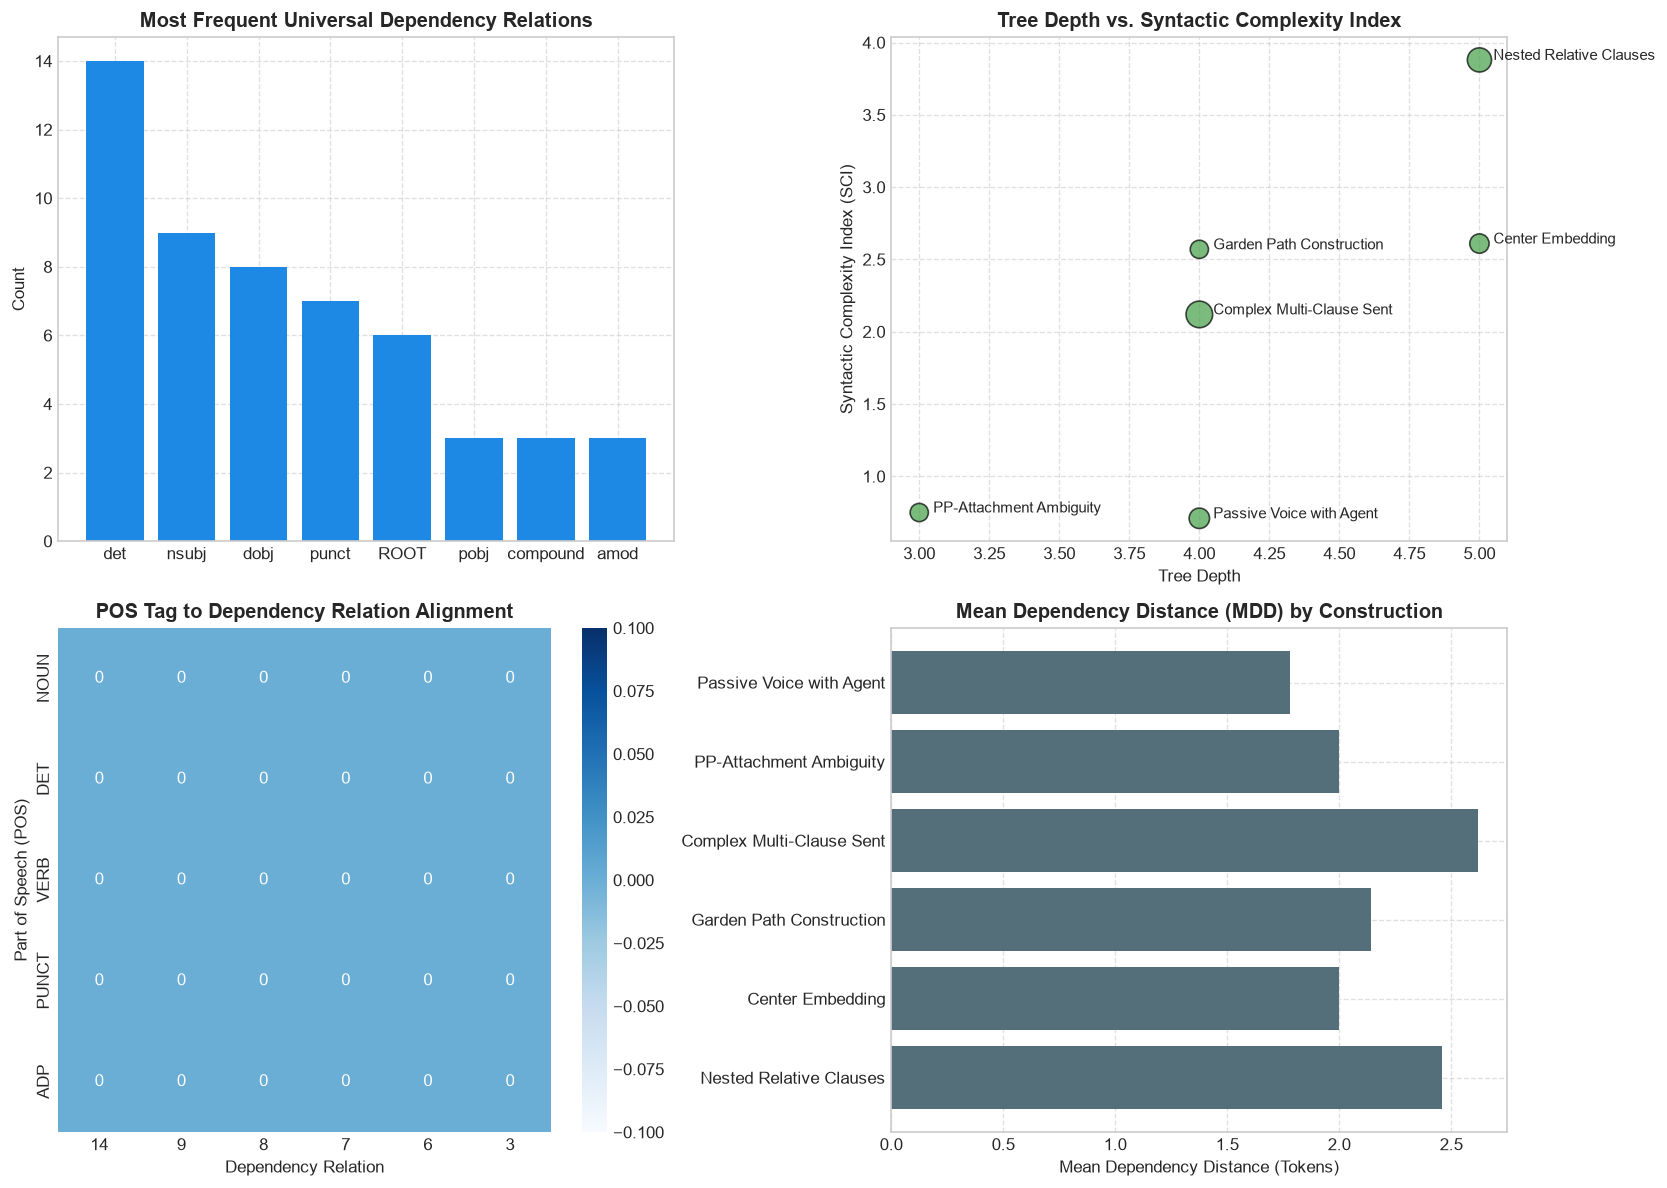

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Viz 1: Dependency Relation Frequency
all_deps   = [token.dep_ for item in linguistic_corpus for token in nlp(item["sentence"])]
dep_counts = Counter(all_deps).most_common(8)
dep_labels, dep_freqs = zip(*dep_counts)
axes[0, 0].bar(dep_labels, dep_freqs, color="#1E88E5")
axes[0, 0].set_title("Most Frequent Universal Dependency Relations", fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel("Count")
axes[0, 0].grid(True, linestyle='--', alpha=0.6)

# Viz 2: Tree Depth vs Syntactic Complexity Index
axes[0, 1].scatter(sci_df["Tree Depth"], sci_df["SCI Score"], s=sci_df["Tokens"]*15, color="#43A047", alpha=0.7, edgecolors="black")
for _, row in sci_df.iterrows():
    axes[0, 1].annotate(row["Category"], (row["Tree Depth"] + 0.05, row["SCI Score"]), fontsize=9)
axes[0, 1].set_title("Tree Depth vs. Syntactic Complexity Index", fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel("Tree Depth")
axes[0, 1].set_ylabel("Syntactic Complexity Index (SCI)")
axes[0, 1].grid(True, linestyle='--', alpha=0.6)

# Viz 3: POS Tag to Dependency Relation Transition Matrix
pairs   = [(token.pos_, token.dep_) for item in linguistic_corpus for token in nlp(item["sentence"])]
top_pos = [p for p, _ in Counter(p for p, d in pairs).most_common(5)]
top_dep = [d for _, d in Counter(d for p, d in pairs).most_common(6)]
trans_mat = np.zeros((len(top_pos), len(top_dep)))
for p, d in pairs:
    if p in top_pos and d in top_dep:
        trans_mat[top_pos.index(p), top_dep.index(d)] += 1

sns.heatmap(trans_mat, annot=True, fmt=".0f", cmap="Blues", xticklabels=top_dep, yticklabels=top_pos, ax=axes[1, 0])
axes[1, 0].set_title("POS Tag to Dependency Relation Alignment", fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel("Dependency Relation")
axes[1, 0].set_ylabel("Part of Speech (POS)")

# Viz 4: MDD across Sentence Constructs
axes[1, 1].barh(sci_df["Category"], sci_df["MDD"], color="#546E7A")
axes[1, 1].set_title("Mean Dependency Distance (MDD) by Construction", fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel("Mean Dependency Distance (Tokens)")
axes[1, 1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


## 10. 🚀 Downstream Task: Dependency-Guided Fact Extraction & QA

Dependency trees provide structured query paths for factual Question Answering. Given a question template *"Who [VERB] [OBJ]?"*, we can trace the verb root to answer questions directly.


In [8]:
def query_dependency_fact(sentence, question_type="who"):
    triples = extract_svo_triples(sentence)
    if not triples:
        return "No factual proposition extracted."
    
    t = triples[0]
    if question_type == "who":
        return f"Agent: {t['Subject (Agent)']} performed '{t['Relation (Predicate)']}' on '{t['Object (Patient)']}'."
    elif question_type == "what":
        return f"Patient: '{t['Object (Patient)']}' was acted upon by '{t['Subject (Agent)']}'."
    return str(t)

sample_s = "The quantum encryption protocol was designed by senior cryptographers."
print("Sentence:", sample_s)
print("Query: 'Who designed the protocol?' ->", query_dependency_fact(sample_s, "who"))
print("Query: 'What was designed?'         ->", query_dependency_fact(sample_s, "what"))


Sentence: The quantum encryption protocol was designed by senior cryptographers.
Query: 'Who designed the protocol?' -> Agent: senior cryptographers performed 'DESIGN' on 'encryption protocol'.
Query: 'What was designed?'         -> Patient: 'encryption protocol' was acted upon by 'senior cryptographers'.


## 11. ⚠️ Edge Cases & Failure Analysis

In [9]:
edge_cases = [
    ("Garden Path Sentence (Misparsed Main Verb)", "The horse raced past the barn fell."),
    ("Center Embedding (Multi-Level Subordination)", "The scientist the journalist interviewed published the study."),
    ("Elliptical Clause (Omitted Copula)", "She ordered espresso, he cappuccino."),
    ("Ungrammatical Input", "Quickly the algorithms learning accurate.")
]

print("=== Syntactic Edge-Case Analysis ===")
for title, s in edge_cases:
    doc = nlp(s)
    root = [t for t in doc if t.head == t][0]
    triples = extract_svo_triples(s)
    print(f"\nScenario: {title}")
    print(f"  Sentence : \"{s}\"")
    print(f"  Root Verb: {root.text} (pos={root.pos_}, dep={root.dep_})")
    print(f"  Extracted Triples: {triples if triples else 'NONE (Parsing degradation)'}")


=== Syntactic Edge-Case Analysis ===

Scenario: Garden Path Sentence (Misparsed Main Verb)
  Sentence : "The horse raced past the barn fell."
  Root Verb: raced (pos=VERB, dep=ROOT)
  Extracted Triples: [{'Subject (Agent)': 'horse', 'Relation (Predicate)': 'RACE', 'Object (Patient)': 'past barn', 'Voice': 'Active'}]

Scenario: Center Embedding (Multi-Level Subordination)
  Sentence : "The scientist the journalist interviewed published the study."
  Root Verb: published (pos=VERB, dep=ROOT)
  Extracted Triples: [{'Subject (Agent)': 'scientist', 'Relation (Predicate)': 'PUBLISH', 'Object (Patient)': 'study', 'Voice': 'Active'}]

Scenario: Elliptical Clause (Omitted Copula)
  Sentence : "She ordered espresso, he cappuccino."
  Root Verb: cappuccino (pos=VERB, dep=ROOT)
  Extracted Triples: [{'Subject (Agent)': 'She', 'Relation (Predicate)': 'ORDER', 'Object (Patient)': 'espresso', 'Voice': 'Active'}]

Scenario: Ungrammatical Input
  Sentence : "Quickly the algorithms learning accurate."
 

## 12. ⏱️ Parsing Latency & Scalability Benchmark

In [10]:
import time

latencies = []
for item in linguistic_corpus:
    s = item["sentence"]
    # Repeat for measurement
    t0 = time.perf_counter()
    for _ in range(50):
        _ = nlp(s)
    elapsed_ms = (time.perf_counter() - t0) / 50 * 1000

    latencies.append({
        "Category": item["category"][:25],
        "Token Count": len(s.split()),
        "Parse Latency (ms)": round(elapsed_ms, 3),
        "Speed (Tokens/sec)": round((len(s.split()) / (elapsed_ms / 1000)), 1)
    })

perf_df = pd.DataFrame(latencies)
print("=== Dependency Parsing Throughput Benchmark ===")
print(tabulate(perf_df, headers="keys", tablefmt="fancy_grid"))


=== Dependency Parsing Throughput Benchmark ===
╒════╤═══════════════════════════╤═══════════════╤══════════════════════╤══════════════════════╕
│    │ Category                  │   Token Count │   Parse Latency (ms) │   Speed (Tokens/sec) │
╞════╪═══════════════════════════╪═══════════════╪══════════════════════╪══════════════════════╡
│  0 │ PP-Attachment Ambiguity   │             7 │                3.658 │               1913.8 │
├────┼───────────────────────────┼───────────────┼──────────────────────┼──────────────────────┤
│  1 │ Passive Voice with Agent  │             9 │                3.661 │               2458   │
├────┼───────────────────────────┼───────────────┼──────────────────────┼──────────────────────┤
│  2 │ Nested Relative Clauses   │            13 │                4.192 │               3100.9 │
├────┼───────────────────────────┼───────────────┼──────────────────────┼──────────────────────┤
│  3 │ Garden Path Construction  │             7 │                3.462 │      

## 13. 🔄 Modular Reusable OOP Pipeline (`AdvancedSyntacticPipeline`)

In [11]:
class AdvancedSyntacticPipeline:
    """Unified End-to-End Syntactic and Semantic Parsing Pipeline."""
    def __init__(self):
        self.nlp = spacy.load("en_core_web_sm")

    def analyze(self, sentence):
        doc = self.nlp(sentence)
        metrics = compute_tree_metrics(doc)
        svo = extract_svo_triples(sentence)
        pp = analyze_pp_attachment(sentence)
        return {
            "Tokens": metrics["Total Tokens"],
            "Tree Depth": metrics["Tree Depth"],
            "Mean Dep Distance": metrics["Mean Dep Distance"],
            "SVO Events": svo,
            "PP Analyses": pp
        }

pipe = AdvancedSyntacticPipeline()
demo_report = pipe.analyze(linguistic_corpus[1]["sentence"])
print("=== Unified Pipeline Analysis Output ===")
print("Metrics   :", {k: demo_report[k] for k in ["Tokens", "Tree Depth", "Mean Dep Distance"]})
print("SVO Events:", demo_report["SVO Events"])


=== Unified Pipeline Analysis Output ===
Metrics   : {'Tokens': 10, 'Tree Depth': 4, 'Mean Dep Distance': np.float64(1.78)}
SVO Events: [{'Subject (Agent)': 'senior cryptographers', 'Relation (Predicate)': 'DESIGN', 'Object (Patient)': 'encryption protocol', 'Voice': 'Passive'}]


## 14. 📝 Final Conclusion & Engineering Takeaways

### Key Learnings
1. **Tree Metrics Quantify Cognitive & Computational Load:** Tree depth and Mean Dependency Distance (MDD) formally quantify syntactic complexity beyond simple token counts.
2. **Robust SVO Extraction Requires Voice Normalization:** By inspecting passive markers (`nsubjpass`, `agent`) alongside active nominal subjects (`nsubj`), the extractor captures invariant semantic roles (*who did what to whom*).
3. **Resolving Structural Ambiguity:** While statistical parsers choose a single tree, heuristic and lexical affinity scoring allows downstream systems to detect and arbitrate alternative Prepositional Phrase attachment interpretations.

**Experiment Status:** `Completed Successfully (Advanced Implementation)`
